<a href="https://colab.research.google.com/github/eternitvy/ML_26/blob/main/JS05/JS05_TUGAS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libary dan memuat data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Memuat dataset
df = pd.read_csv('voice.csv')

# Menampilkan 5 baris pertama data
display(df.head())

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
# Encoding label
# Mengubah label teks menjadi numerik (misal: male = 1, female = 0)
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

print("Cek mapping label:", dict(zip(le.classes_, le.transform(le.classes_))))

Cek mapping label: {'female': np.int64(0), 'male': np.int64(1)}


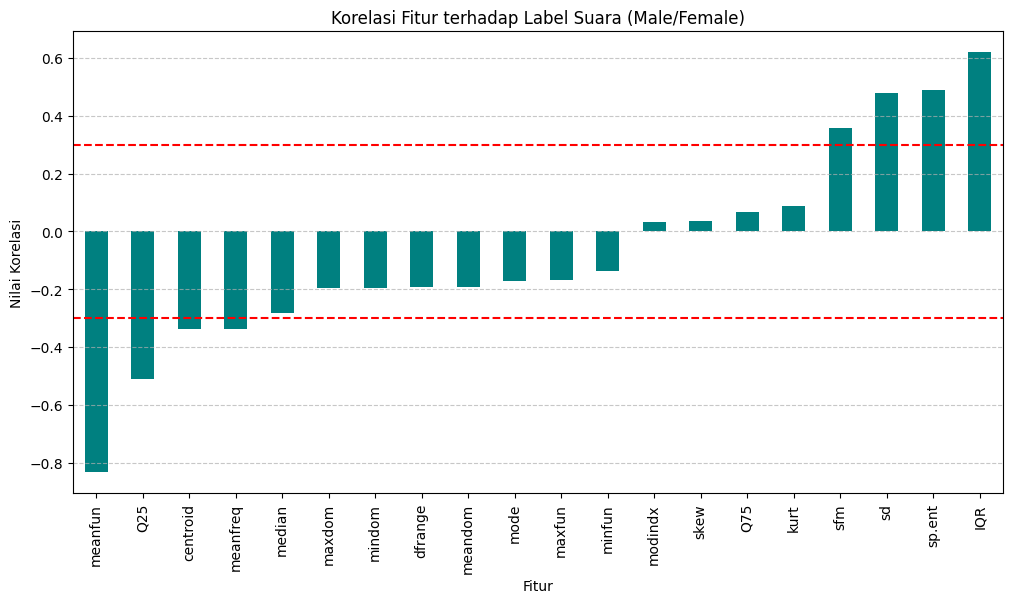


 HASIL ANALISIS FITUR 
Fitur yang paling optimal digunakan ada 8 fitur, yaitu:
['meanfreq', 'sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'centroid', 'meanfun']


In [3]:
# Seleksi fitur yang paling optimal
# Menghitung korelasi fitur dengan kolom label
correlation = df.corr()

# Visualisasi korelasi fitur terhadap label
plt.figure(figsize=(12, 6))
correlation['label'].drop('label').sort_values().plot(kind='bar', color='teal')
plt.title('Korelasi Fitur terhadap Label Suara (Male/Female)')
plt.ylabel('Nilai Korelasi')
plt.xlabel('Fitur')
plt.axhline(y=0.3, color='r', linestyle='--') # Garis batas korelasi positif
plt.axhline(y=-0.3, color='r', linestyle='--') # Garis batas korelasi negatif
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Memilih fitur dengan nilai korelasi absolut lebih dari 0.3 (threshold optimal)
corr_target = abs(correlation['label'])
optimal_features = corr_target[corr_target > 0.3].drop('label').index.tolist()

print("\n HASIL ANALISIS FITUR ")
print(f"Fitur yang paling optimal digunakan ada {len(optimal_features)} fitur, yaitu:")
print(optimal_features)

In [4]:
# Pembagian data(train/test) dan standardiasi

# Gunakan hanya fitur-fitur optimal yang telah diseleksi
X = df[optimal_features]
y = df['label']

# Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Melakukan scaling (standardisasi) agar skala data sama
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Jumlah data latih:", X_train_scaled.shape[0])
print("Jumlah data uji:", X_test_scaled.shape[0])

Jumlah data latih: 2534
Jumlah data uji: 634


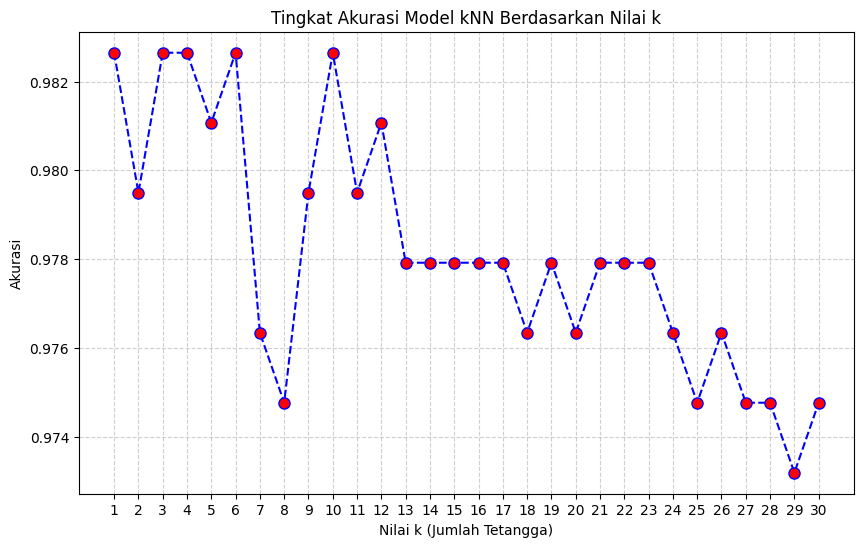


Berdasarkan grafik, nilai k terbaik adalah k = 1
Akurasi maksimal yang didapat: 98.26%


In [5]:
# Mencari nilai k terbaik
k_values = range(1, 31)
accuracies = []

# Uji model kNN dengan berbagai nilai k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot grafik akurasi vs nilai k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='blue',
         markerfacecolor='red', markersize=8)
plt.title('Tingkat Akurasi Model kNN Berdasarkan Nilai k')
plt.xlabel('Nilai k (Jumlah Tetangga)')
plt.ylabel('Akurasi')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Mencari nilai k dengan akurasi tertinggi
best_k = k_values[np.argmax(accuracies)]
max_accuracy = max(accuracies)

print(f"\nBerdasarkan grafik, nilai k terbaik adalah k = {best_k}")
print(f"Akurasi maksimal yang didapat: {max_accuracy * 100:.2f}%")

--- EVALUASI MODEL FINAL (k = 1) ---
              precision    recall  f1-score   support

      Female       0.99      0.98      0.98       317
        Male       0.98      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



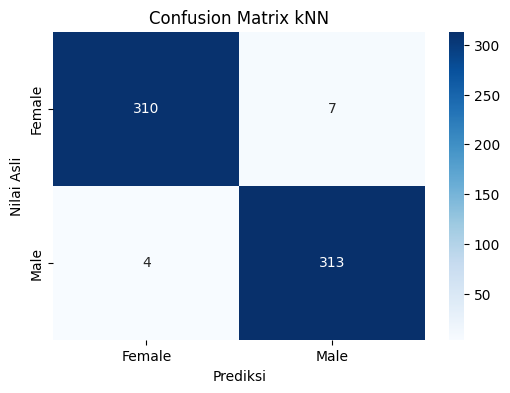

In [6]:
# Evaluasi akhir menggunakn k terbaik
# Membangun ulang model dengan nilai k terbaik
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

# Prediksi data uji
final_predictions = final_knn.predict(X_test_scaled)

# Menampilkan Laporan Evaluasi
print(f"--- EVALUASI MODEL FINAL (k = {best_k}) ---")
print(classification_report(y_test, final_predictions, target_names=['Female', 'Male']))

# Menampilkan Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.title('Confusion Matrix kNN')
plt.ylabel('Nilai Asli')
plt.xlabel('Prediksi')
plt.show()